# Modeling

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf

## Data exploration

In [3]:
reviews10 = gpd.read_file("data/reviews_demog10.gpkg")
reviews20 = gpd.read_file("data/reviews_demog20.gpkg")

In [4]:
reviews10.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'review_id', 'user_id',
       'useful', 'funny', 'cool', 'text', 'date', 'brewery', 'index_right',
       'GentYN', 'TRACTCE10', 'GEO_ID', 'tot_pop', 'prop_black', 'prop_asian',
       'prop_hispanic_or_latino', 'prop_white_only', 'med_prop_val', 'med_inc',
       'total_25_plus', 'pct_bachelor_or_higher', 'pct_bachelor_lower',
       'geometry'],
      dtype='object')

In [11]:
tract_agg10 = reviews10.groupby("GEO_ID").agg(
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first")
)
tract_agg10.head()


,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified
GEO_ID,,,,,,,,
42101000100,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,72.3,0.0
42101000200,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,33.3,0.0
42101000300,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,68.8,0.0
42101000401,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,71.5,0.0
42101000402,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,58.9,0.0


In [16]:
tract_agg20 = reviews20.groupby("GEO_ID").agg(
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first")
)
tract_agg20.head()

,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified
GEO_ID,,,,,,,,
42101000101,0.064704,0.054959,0.101331,0.055818,93462.0,104458.0,91.627635,0.0
42101000102,0.004049,0.050698,0.100826,0.059242,98400.0,104236.0,81.796783,0.0
42101000200,0.000000,0.084942,0.634096,0.037125,190300.0,83854.0,50.237530,0.0
42101000300,0.152015,0.080427,0.158631,0.061986,75611.0,84843.0,82.147743,0.0
42101000401,0.000000,0.089657,0.276977,0.053474,145592.0,73438.0,81.802351,0.0


In [17]:
print(tract_agg10.shape[0])
print(tract_agg20.shape[0])

384
408


(array([311.,  15.,   5.,   7.,   1.,   4.,   2.,   1.,   1.,   0.,   2.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

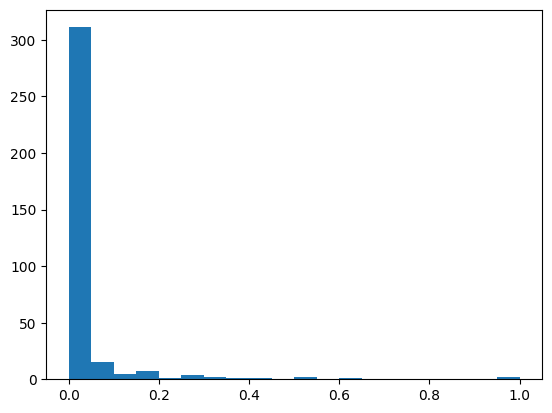

In [20]:
plt.hist(tract_agg20["mean_brew_reviews"], bins=20)

## Simple logistic regression models

In [15]:
mod_pre_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg10).fit()

mod_pre_1.summary()

Optimization terminated successfully.
         Current function value: 0.357628
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  233
Model:                          Logit   Df Residuals:                      225
Method:                           MLE   Df Model:                            7
Date:                Sun, 24 May 2026   Pseudo R-squ.:                 0.08801
Time:                        21:09:15   Log-Likelihood:                -83.327
converged:                       True   LL-Null:                       -91.368
Covariance Type:            nonrobust   LLR p-value:                   0.02438
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.7906      1.107      0.714      0.475      -1.379       2.961
mean_brew_reviews           4.2704      2.011      2.123      0.034       0.329       8.212
prop_black                 -1.3783      0.897     -1.536      0.124      -3.137       0.380
prop_asian                  0.9848      1.038      0.949      0.343      -1.050       3.019
prop_hispanic_or_latino    -1.8639      1.579     -1.181      0.238      -4.958       1.231
med_prop_val             -7.05e-06   4.37e-06     -1.615      0.106   -1.56e-05    1.51e-06
med_inc                 -3.976e-05   1.85e-05     -2.146      0.032   -7.61e-05   -3.45e-06
pct_bachelor_or_higher      0.0189      0.019      0.978      0.328      -0.019       0.057
===========================================================================================
"""

In [21]:
mod_post_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg20).fit()

mod_post_1.summary()

Optimization terminated successfully.
         Current function value: 0.335132
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  328
Model:                          Logit   Df Residuals:                      320
Method:                           MLE   Df Model:                            7
Date:                Sun, 24 May 2026   Pseudo R-squ.:                 0.06540
Time:                        21:10:23   Log-Likelihood:                -109.92
converged:                       True   LL-Null:                       -117.61
Covariance Type:            nonrobust   LLR p-value:                   0.03139
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.9186      1.002     -2.911      0.004      -4.883      -0.954
mean_brew_reviews           1.8714      1.367      1.369      0.171      -0.808       4.551
prop_black                 -0.2373      0.924     -0.257      0.797      -2.049       1.574
prop_asian                  1.4267      2.244      0.636      0.525      -2.971       5.824
prop_hispanic_or_latino    -0.7435      1.873     -0.397      0.691      -4.414       2.927
med_prop_val            -3.234e-06   3.73e-06     -0.868      0.386   -1.05e-05    4.07e-06
med_inc                  6.591e-06   9.29e-06      0.710      0.478   -1.16e-05    2.48e-05
pct_bachelor_or_higher      0.0145      0.013      1.108      0.268      -0.011       0.040
===========================================================================================
"""